In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/raw/Dataset.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (17880, 18)

Column names:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'in_balanced_dataset']

First 5 rows:


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


In [2]:
# Check missing values in each column

missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0].sort_values(ascending=False))

Missing values:
salary_range           15012
department             11547
required_education      8105
benefits                7196
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2689
location                 346
dtype: int64


Fraud distribution:
fraudulent
f    17014
t      866
Name: count, dtype: int64


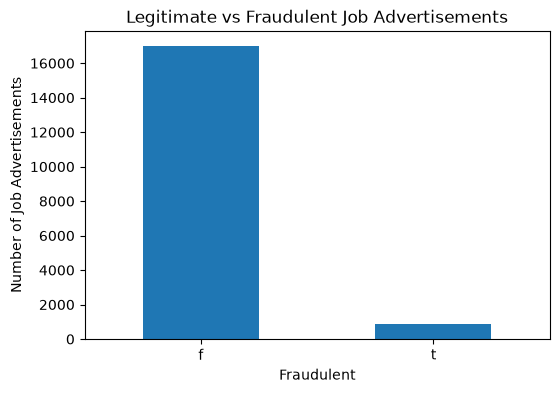

In [3]:
import matplotlib.pyplot as plt

# Count legitimate and fraudulent job advertisements
fraud_counts = df["fraudulent"].value_counts()

print("Fraud distribution:")
print(fraud_counts)

# Plot
plt.figure(figsize=(6, 4))
fraud_counts.plot(kind="bar")
plt.title("Legitimate vs Fraudulent Job Advertisements")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Job Advertisements")
plt.xticks(rotation=0)
plt.show()

In [4]:
# Check for exact duplicate job advertisements

duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)
print("Percentage of exact duplicates:", round(duplicate_count / len(df) * 100, 2), "%")

Number of exact duplicate rows: 235
Percentage of exact duplicates: 1.31 %


In [5]:
# Analyze fraud labels among duplicate rows

duplicate_rows = df[df.duplicated(keep=False)]

print("Total rows involved in exact duplicates:", len(duplicate_rows))

print("\nFraudulent distribution among duplicate rows:")
print(duplicate_rows["fraudulent"].value_counts())

print("\nPercentage fraudulent among duplicate rows:")
print(
    duplicate_rows["fraudulent"]
    .value_counts(normalize=True).mul(100).round(2)
)

Total rows involved in exact duplicates: 439

Fraudulent distribution among duplicate rows:
fraudulent
f    425
t     14
Name: count, dtype: int64

Percentage fraudulent among duplicate rows:
fraudulent
f    96.81
t     3.19
Name: proportion, dtype: float64


In [6]:
# Check duplicate job descriptions

description_duplicates = df["description"].duplicated(keep=False).sum()

print("Rows with duplicate descriptions:", description_duplicates)
print(
    "Percentage of rows with duplicate descriptions:",
    round(description_duplicates / len(df) * 100, 2),
    "%"
)

Rows with duplicate descriptions: 3837
Percentage of rows with duplicate descriptions: 21.46 %


In [7]:
# Check whether identical job descriptions have different fraud labels

description_groups = (
    df.dropna(subset=["description"])
      .groupby("description")["fraudulent"]
      .nunique()
)

conflicting_descriptions = (description_groups > 1).sum()

print("Unique descriptions with conflicting fraud labels:",
      conflicting_descriptions)

print(
    "Percentage of duplicate descriptions with conflicting labels:",
    round(conflicting_descriptions / len(description_groups) * 100, 2),
    "%"
)

Unique descriptions with conflicting fraud labels: 1
Percentage of duplicate descriptions with conflicting labels: 0.01 %


In [8]:
# Find the description that has conflicting fraud labels

conflicting_description = description_groups[
    description_groups > 1
].index[0]

conflicting_rows = df[
    df["description"] == conflicting_description
][["title", "description", "fraudulent"]]

print(conflicting_rows.to_string(index=False))

                        title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [9]:
# Calculate description length

df["description_length"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.len()
)

print("Description length statistics:")
print(df["description_length"].describe())

Description length statistics:
count    17880.000000
mean      1438.563423
std       1715.209068
min         10.000000
25%        676.000000
50%       1158.000000
75%       1775.250000
max      55130.000000
Name: description_length, dtype: float64


In [10]:
# Compare description length between legitimate and fraudulent ads

length_by_fraud = df.groupby("fraudulent")["description_length"].agg(
    ["count", "mean", "median", "min", "max"]
)

print(length_by_fraud)

            count         mean  median  min    max
fraudulent                                        
f           17014  1438.673387  1166.0   42  55130
t             866  1436.403002   975.5   10  29424


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/Dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (17880, 18)


In [3]:
# Fraud rate for selected categorical features

categorical_features = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type"
]

for col in categorical_features:
    print(f"\n--- {col} ---")
    print(pd.crosstab(
        df[col],
        df["fraudulent"],
        normalize="index"
    ).round(3))


--- telecommuting ---
fraudulent         f      t
telecommuting              
f              0.953  0.047
t              0.917  0.083

--- has_company_logo ---
fraudulent            f      t
has_company_logo              
f                 0.841  0.159
t                 0.980  0.020

--- has_questions ---
fraudulent         f      t
has_questions              
f              0.932  0.068
t              0.972  0.028

--- employment_type ---
fraudulent           f      t
employment_type              
Contract         0.971  0.029
Full-time        0.958  0.042
Other            0.934  0.066
Part-time        0.907  0.093
Temporary        0.992  0.008


In [4]:
# Analyze industry and job function

for col in ["industry", "function"]:
    print(f"\n--- {col}: Top categories by number of job ads ---")

    counts = df[col].fillna("Missing").value_counts().head(15)
    print(counts)


--- industry: Top categories by number of job ads ---
industry
Missing                                4903
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
Name: count, dtype: int64

--- function: Top categories by number of job ads ---
function
Missing                   6455
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830


In [5]:
# Fraud rate by industry

industry_fraud = pd.crosstab(
    df["industry"].fillna("Missing"),
    df["fraudulent"],
    normalize="index"
)

industry_fraud["fraud_rate"] = industry_fraud.get("t", 0) * 100

print(
    industry_fraud["fraud_rate"]
    .sort_values(ascending=False)
    .head(15)
)

industry
Ranching                           100.000000
Military                            50.000000
Animation                           40.000000
Oil & Energy                        37.979094
Accounting                          35.849057
Leisure, Travel & Tourism           27.631579
Computer Networking                 27.272727
Executive Office                    25.000000
Defense & Space                     22.222222
Business Supplies and Equipment     16.666667
Investment Management               16.666667
Hospitality                         15.909091
Public Safety                       14.285714
Real Estate                         13.714286
Health, Wellness and Fitness        11.811024
Name: fraud_rate, dtype: float64


In [6]:
# Fraud rate by industry for categories with at least 50 job ads

industry_counts = df["industry"].fillna("Missing").value_counts()

valid_industries = industry_counts[industry_counts >= 50].index

industry_fraud_rate = (
    df[df["industry"].fillna("Missing").isin(valid_industries)]
    .groupby(df["industry"].fillna("Missing"))["fraudulent"]
    .apply(lambda x: (x == "t").mean() * 100)
    .sort_values(ascending=False)
)

print(industry_fraud_rate)

industry
Oil & Energy                           37.979094
Accounting                             35.849057
Leisure, Travel & Tourism              27.631579
Hospitality                            15.909091
Real Estate                            13.714286
Health, Wellness and Fitness           11.811024
Hospital & Health Care                 10.261569
Telecommunications                      7.602339
Entertainment                           6.756757
Consumer Services                       6.703911
Staffing and Recruiting                 6.299213
Transportation/Trucking/Railroad        5.660377
Missing                                 5.608811
Human Resources                         5.555556
Electrical/Electronic Manufacturing     5.479452
Marketing and Advertising               5.434783
Insurance                               4.878049
Management Consulting                   4.615385
Financial Services                      4.492940
Automotive                              4.166667
Market Rese

In [7]:
# Analyze job advertisement locations

print("Total unique locations:", df["location"].nunique())

print("\nMissing locations:", df["location"].isna().sum())

print("\nTop 20 locations:")
print(df["location"].fillna("Missing").value_counts().head(20))

Total unique locations: 3105

Missing locations: 346

Top 20 locations:
location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
Missing                  346
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
NZ, N, Auckland          218
US, CA, Los Angeles      185
GB, , London             179
US, TX, Austin           174
US, CA, San Diego        164
GB, ,                    138
US, GA, Atlanta          135
GB, LND,                 131
US, OR, Portland         131
CA, ON, Toronto          123
Name: count, dtype: int64


In [8]:
# Analyze job advertisement titles

print("Unique job titles:", df["title"].nunique())

print("\nMissing titles:", df["title"].isna().sum())

print("\nTop 20 job titles:")
print(df["title"].fillna("Missing").value_counts().head(20))

print("\nFraudulent job titles:")
print(
    df[df["fraudulent"] == "t"]["title"]
    .fillna("Missing")
    .value_counts()
    .head(20)
)

Unique job titles: 11231

Missing titles: 0

Top 20 job titles:
title
English Teacher Abroad                                311
Customer Service Associate                            146
Graduates: English Teacher Abroad (Conversational)    144
English Teacher Abroad                                 95
Software Engineer                                      86
English Teacher Abroad (Conversational)                83
Customer Service Associate - Part Time                 76
Account Manager                                        75
Web Developer                                          66
Project Manager                                        62
Beauty & Fragrance consultants needed                  60
Graduates: English Teacher Abroad                      57
Customer Service Representative                        51
Administrative Assistant                               48
Product Manager                                        47
Office Manager                                         46
Cu

In [9]:
# Analyze job title length

df["title_length"] = df["title"].astype(str).str.len()

print("Overall title length:")
print(df["title_length"].describe())

print("\nTitle length by class:")
print(
    df.groupby("fraudulent")["title_length"]
    .agg(["count", "mean", "median", "min", "max"])
)

Overall title length:
count    17880.000000
mean        28.530313
std         13.871256
min          3.000000
25%         19.000000
50%         25.000000
75%         35.000000
max        142.000000
Name: title_length, dtype: float64

Title length by class:
            count       mean  median  min  max
fraudulent                                    
f           17014  28.421594    25.0    3  110
t             866  30.666282    28.0    3  142


In [10]:
# Analyze missing values in important text fields

text_features = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

print("Missing values in text fields:\n")

for col in text_features:
    missing = df[col].isna().sum()
    percentage = (missing / len(df)) * 100
    
    print(f"{col}: {missing} missing ({percentage:.2f}%)")

Missing values in text fields:

title: 0 missing (0.00%)
company_profile: 3308 missing (18.50%)
description: 0 missing (0.00%)
requirements: 2689 missing (15.04%)
benefits: 7196 missing (40.25%)


In [12]:
# Compare missing text fields between legitimate and fraudulent ads

for col in ["company_profile", "requirements", "benefits"]:
    missing_rate = (
        df.groupby("fraudulent")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )
    
    print(f"\n{col}")
    print(missing_rate.round(2))


company_profile
fraudulent
f    15.99
t    67.78
Name: company_profile, dtype: float64

requirements
fraudulent
f    14.91
t    17.67
Name: requirements, dtype: float64

benefits
fraudulent
f    40.16
t    41.92
Name: benefits, dtype: float64


In [13]:
# Check the in_balanced_dataset column

print("Values in in_balanced_dataset:")
print(df["in_balanced_dataset"].value_counts(dropna=False))

print("\nCross-tabulation with fraud:")
print(pd.crosstab(
    df["in_balanced_dataset"],
    df["fraudulent"],
    normalize="index"
).round(3))

Values in in_balanced_dataset:
in_balanced_dataset
f    16980
t      900
Name: count, dtype: int64

Cross-tabulation with fraud:
fraudulent               f      t
in_balanced_dataset              
f                    0.976  0.024
t                    0.500  0.500


In [14]:
# Combine important text fields into one text feature

text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df[col] = df[col].fillna("")

df["combined_text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

print("Combined text created successfully.")

print("\nExample:")
print(df["combined_text"].iloc[0][:1000])

print("\nCombined text length:")
print(df["combined_text"].str.len().describe())

Combined text created successfully.

Example:
Marketing Intern <h3>We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.</h3>
<p>We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.</p>
<p>Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.</p>
<p>We're located in Chelsea, in New York City.</p> <p>Food52, a fast-

In [15]:
import re

def clean_text(text):
    text = str(text).lower()
    
    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Keep letters and numbers
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df["clean_text"] = df["combined_text"].apply(clean_text)

print("Text cleaning completed.")

print("\nOriginal:")
print(df["combined_text"].iloc[0][:500])

print("\nCleaned:")
print(df["clean_text"].iloc[0][:500])

Text cleaning completed.

Original:
Marketing Intern <h3>We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.</h3>
<p>We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks a

Cleaned:
marketing intern we re food52 and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top editorial business and engineering team we re focused on using technology to find new and better ways to connect people around their specific food interests and to offer them superb highly curated information about food and cooking we attract the most 

In [16]:
# Create target variable

df["target"] = df["fraudulent"].map({
    "f": 0,
    "t": 1
})

print("Target distribution:")
print(df["target"].value_counts())

print("\nTarget percentages:")
print((df["target"].value_counts(normalize=True) * 100).round(2))

Target distribution:
target
0    17014
1      866
Name: count, dtype: int64

Target percentages:
target
0    95.16
1     4.84
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTraining fraud percentage:",
      round(y_train.mean() * 100, 2), "%")

print("Testing fraud percentage:",
      round(y_test.mean() * 100, 2), "%")

Training samples: 14304
Testing samples: 3576

Training class distribution:
target
0    13611
1      693
Name: count, dtype: int64

Testing class distribution:
target
0    3403
1     173
Name: count, dtype: int64

Training fraud percentage: 4.84 %
Testing fraud percentage: 4.84 %


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Learn vocabulary only from training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data using the same vocabulary
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed successfully.")

print("\nTraining TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

print("\nNumber of features:", len(tfidf.get_feature_names_out()))

TF-IDF completed successfully.

Training TF-IDF shape: (14304, 10000)
Testing TF-IDF shape: (3576, 10000)

Number of features: 10000


In [19]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

# Make predictions
y_pred = lr_model.predict(X_test_tfidf)

# Get fraud probabilities
y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Basic accuracy
accuracy = accuracy_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# PR-AUC
pr_auc = average_precision_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9757
ROC-AUC: 0.9902
PR-AUC: 0.9195

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9943    0.9800    0.9871      3403
  Fraudulent     0.6937    0.8902    0.7797       173

    accuracy                         0.9757      3576
   macro avg     0.8440    0.9351    0.8834      3576
weighted avg     0.9798    0.9757    0.9771      3576

Confusion Matrix:
[[3335   68]
 [  19  154]]


In [21]:
# Check duplicate descriptions in train and test sets

train_indices = X_train.index
test_indices = X_test.index

train_descriptions = set(
    df.loc[train_indices, "description"].fillna("")
)

test_descriptions = set(
    df.loc[test_indices, "description"].fillna("")
)

overlap = train_descriptions.intersection(test_descriptions)

print("Unique descriptions in training:", len(train_descriptions))
print("Unique descriptions in testing:", len(test_descriptions))
print("Descriptions appearing in both:", len(overlap))

Unique descriptions in training: 12239
Unique descriptions in testing: 3295
Descriptions appearing in both: 439


In [22]:
# Measure duplicate-description leakage at the row level

train_description_set = set(
    df.loc[X_train.index, "description"].fillna("")
)

test_duplicate_mask = (
    df.loc[X_test.index, "description"]
    .fillna("")
    .isin(train_description_set)
)

print("Test advertisements with descriptions seen in training:",
      test_duplicate_mask.sum())

print("Percentage of test advertisements affected:",
      round(test_duplicate_mask.mean() * 100, 2), "%")

print("\nFraud distribution among overlapping test advertisements:")
print(
    df.loc[X_test.index[test_duplicate_mask], "fraudulent"]
    .value_counts()
)

Test advertisements with descriptions seen in training: 687
Percentage of test advertisements affected: 19.21 %

Fraud distribution among overlapping test advertisements:
fraudulent
f    635
t     52
Name: count, dtype: int64


In [23]:
from sklearn.model_selection import GroupShuffleSplit

# Use description as the grouping variable
groups = df["description"].fillna("")

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(df, df["target"], groups=groups)
)

X_group_train = df.loc[train_idx, "clean_text"]
X_group_test = df.loc[test_idx, "clean_text"]

y_group_train = df.loc[train_idx, "target"]
y_group_test = df.loc[test_idx, "target"]

print("Group-aware training samples:", len(X_group_train))
print("Group-aware testing samples:", len(X_group_test))

print("\nTraining class distribution:")
print(y_group_train.value_counts())

print("\nTesting class distribution:")
print(y_group_test.value_counts())

Group-aware training samples: 14019
Group-aware testing samples: 3861

Training class distribution:
target
0    13305
1      714
Name: count, dtype: int64

Testing class distribution:
target
0    3709
1     152
Name: count, dtype: int64


In [24]:
# Verify no duplicate descriptions cross the group-aware split

group_train_descriptions = set(
    df.loc[train_idx, "description"].fillna("")
)

group_test_descriptions = set(
    df.loc[test_idx, "description"].fillna("")
)

group_overlap = group_train_descriptions.intersection(
    group_test_descriptions
)

print("Descriptions appearing in both group-aware sets:",
      len(group_overlap))

Descriptions appearing in both group-aware sets: 0


In [25]:
# TF-IDF for leakage-resistant evaluation

tfidf_group = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_group_train_tfidf = tfidf_group.fit_transform(X_group_train)
X_group_test_tfidf = tfidf_group.transform(X_group_test)

print("Group-aware TF-IDF completed.")

print("Training shape:", X_group_train_tfidf.shape)
print("Testing shape:", X_group_test_tfidf.shape)

Group-aware TF-IDF completed.
Training shape: (14019, 10000)
Testing shape: (3861, 10000)


In [26]:
# Train Logistic Regression on group-aware split

lr_group_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_group_model.fit(
    X_group_train_tfidf,
    y_group_train
)

print("Group-aware Logistic Regression trained successfully.")

Group-aware Logistic Regression trained successfully.


In [27]:
# Evaluate group-aware Logistic Regression

y_group_pred = lr_group_model.predict(X_group_test_tfidf)
y_group_prob = lr_group_model.predict_proba(X_group_test_tfidf)[:, 1]

group_accuracy = accuracy_score(y_group_test, y_group_pred)
group_roc_auc = roc_auc_score(y_group_test, y_group_prob)
group_pr_auc = average_precision_score(y_group_test, y_group_prob)

print("Accuracy:", round(group_accuracy, 4))
print("ROC-AUC:", round(group_roc_auc, 4))
print("PR-AUC:", round(group_pr_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_group_test,
    y_group_pred,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(y_group_test, y_group_pred))

Accuracy: 0.9759
ROC-AUC: 0.986
PR-AUC: 0.8752

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9948    0.9800    0.9874      3709
  Fraudulent     0.6425    0.8750    0.7409       152

    accuracy                         0.9759      3861
   macro avg     0.8187    0.9275    0.8642      3861
weighted avg     0.9809    0.9759    0.9777      3861

Confusion Matrix:
[[3635   74]
 [  19  133]]


In [28]:
# Inspect structured metadata columns

metadata_columns = [
    "telecommuting",
    "has_company_logo",
    "has_questions",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "location"
]

print("Metadata columns:")

for col in metadata_columns:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].fillna("Missing").value_counts().head(10))

Metadata columns:

--- telecommuting ---
Unique values: 2
telecommuting
f    17113
t      767
Name: count, dtype: int64

--- has_company_logo ---
Unique values: 2
has_company_logo
t    14220
f     3660
Name: count, dtype: int64

--- has_questions ---
Unique values: 2
has_questions
f    9088
t    8792
Name: count, dtype: int64

--- employment_type ---
Unique values: 5
employment_type
Full-time    11620
Missing       3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

--- required_experience ---
Unique values: 7
required_experience
Missing             7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

--- required_education ---
Unique values: 13
required_education
Missing                              8105
Bachelor's Degree                    5145
High School or equivalent        

In [29]:
# Create metadata features

metadata = pd.DataFrame(index=df.index)

# Binary features
metadata["telecommuting"] = (df["telecommuting"] == "t").astype(int)
metadata["has_company_logo"] = (df["has_company_logo"] == "t").astype(int)
metadata["has_questions"] = (df["has_questions"] == "t").astype(int)

# Missing-value indicators
metadata["company_profile_missing"] = df["company_profile"].isna().astype(int)
metadata["requirements_missing"] = df["requirements"].isna().astype(int)
metadata["benefits_missing"] = df["benefits"].isna().astype(int)
metadata["salary_missing"] = df["salary_range"].isna().astype(int)
metadata["employment_type_missing"] = df["employment_type"].isna().astype(int)
metadata["education_missing"] = df["required_education"].isna().astype(int)
metadata["experience_missing"] = df["required_experience"].isna().astype(int)
metadata["industry_missing"] = df["industry"].isna().astype(int)
metadata["function_missing"] = df["function"].isna().astype(int)
metadata["location_missing"] = df["location"].isna().astype(int)

print("Metadata features created successfully.")

print("\nShape:", metadata.shape)

print("\nFirst 5 rows:")
display(metadata.head())

Metadata features created successfully.

Shape: (17880, 13)

First 5 rows:


,telecommuting,has_company_logo,has_questions,company_profile_missing,requirements_missing,benefits_missing,salary_missing,employment_type_missing,education_missing,experience_missing,industry_missing,function_missing,location_missing
0,0,1,0,0,0,0,1,0,1,0,1,0,0
1,0,1,0,0,0,0,1,0,1,0,0,0,0
2,0,1,0,0,0,0,1,1,1,1,1,1,0
3,0,1,0,0,0,0,1,0,0,0,0,0,0
4,0,1,1,0,0,0,1,0,0,0,0,0,0


In [30]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

categorical_data = df[categorical_columns].fillna("Missing")

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

categorical_encoded = encoder.fit_transform(categorical_data)

print("Categorical encoding completed.")

print("Encoded shape:", categorical_encoded.shape)

print("Number of categorical features:",
      len(encoder.get_feature_names_out()))

Categorical encoding completed.
Encoded shape: (17880, 198)
Number of categorical features: 198


In [31]:
# Split metadata and categorical data using the existing train/test indices

metadata_train = metadata.loc[X_train.index]
metadata_test = metadata.loc[X_test.index]

categorical_train = df.loc[X_train.index, categorical_columns].fillna("Missing")
categorical_test = df.loc[X_test.index, categorical_columns].fillna("Missing")

# Fit encoder ONLY on training data
encoder_final = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

categorical_train_encoded = encoder_final.fit_transform(categorical_train)
categorical_test_encoded = encoder_final.transform(categorical_test)

print("Metadata train shape:", metadata_train.shape)
print("Metadata test shape:", metadata_test.shape)

print("Categorical train shape:", categorical_train_encoded.shape)
print("Categorical test shape:", categorical_test_encoded.shape)

Metadata train shape: (14304, 13)
Metadata test shape: (3576, 13)
Categorical train shape: (14304, 196)
Categorical test shape: (3576, 196)


In [32]:
from scipy.sparse import hstack, csr_matrix

# Convert binary/missing metadata to sparse format
metadata_train_sparse = csr_matrix(metadata_train.values)
metadata_test_sparse = csr_matrix(metadata_test.values)

# Combine all features
X_hybrid_train = hstack([
    X_train_tfidf,
    categorical_train_encoded,
    metadata_train_sparse
])

X_hybrid_test = hstack([
    X_test_tfidf,
    categorical_test_encoded,
    metadata_test_sparse
])

print("Hybrid feature matrix created successfully.")

print("Hybrid training shape:", X_hybrid_train.shape)
print("Hybrid testing shape:", X_hybrid_test.shape)

Hybrid feature matrix created successfully.
Hybrid training shape: (14304, 10209)
Hybrid testing shape: (3576, 10209)


In [33]:
from sklearn.linear_model import LogisticRegression

hybrid_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

hybrid_model.fit(X_hybrid_train, y_train)

print("Hybrid Logistic Regression model trained successfully.")

Hybrid Logistic Regression model trained successfully.


In [34]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

# Predictions
y_hybrid_pred = hybrid_model.predict(X_hybrid_test)
y_hybrid_prob = hybrid_model.predict_proba(X_hybrid_test)[:, 1]

# Metrics
hybrid_accuracy = accuracy_score(y_test, y_hybrid_pred)
hybrid_roc_auc = roc_auc_score(y_test, y_hybrid_prob)
hybrid_pr_auc = average_precision_score(y_test, y_hybrid_prob)

print("Hybrid Model Results")
print("--------------------")
print("Accuracy:", round(hybrid_accuracy, 4))
print("ROC-AUC:", round(hybrid_roc_auc, 4))
print("PR-AUC:", round(hybrid_pr_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_hybrid_pred,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_hybrid_pred))

Hybrid Model Results
--------------------
Accuracy: 0.9698
ROC-AUC: 0.9912
PR-AUC: 0.923

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9961    0.9721    0.9839      3403
  Fraudulent     0.6275    0.9249    0.7477       173

    accuracy                         0.9698      3576
   macro avg     0.8118    0.9485    0.8658      3576
weighted avg     0.9783    0.9698    0.9725      3576

Confusion Matrix:
[[3308   95]
 [  13  160]]


In [35]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.91, 0.05)

print("Threshold | Precision | Recall | F1")
print("--------------------------------------")

for threshold in thresholds:
    y_threshold_pred = (y_hybrid_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_threshold_pred)
    recall = recall_score(y_test, y_threshold_pred)
    f1 = f1_score(y_test, y_threshold_pred)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"{f1:6.4f}"
    )

Threshold | Precision | Recall | F1
--------------------------------------
     0.10 |    0.2272 | 0.9942 | 0.3699
     0.15 |    0.2931 | 0.9827 | 0.4515
     0.20 |    0.3470 | 0.9769 | 0.5121
     0.25 |    0.3907 | 0.9711 | 0.5572
     0.30 |    0.4395 | 0.9653 | 0.6040
     0.35 |    0.4827 | 0.9653 | 0.6435
     0.40 |    0.5309 | 0.9422 | 0.6792
     0.45 |    0.5941 | 0.9306 | 0.7252
     0.50 |    0.6275 | 0.9249 | 0.7477
     0.55 |    0.6723 | 0.9249 | 0.7786
     0.60 |    0.7162 | 0.9191 | 0.8051
     0.65 |    0.7828 | 0.8960 | 0.8356
     0.70 |    0.8371 | 0.8613 | 0.8490
     0.75 |    0.8659 | 0.8208 | 0.8427
     0.80 |    0.9067 | 0.7861 | 0.8421
     0.85 |    0.9528 | 0.6994 | 0.8067
     0.90 |    0.9907 | 0.6127 | 0.7571


In [36]:
from sklearn.model_selection import train_test_split

# Split the original training data into:
# 80% actual training
# 20% validation
X_train_hybrid, X_val_hybrid, y_train_hybrid, y_val_hybrid = train_test_split(
    X_hybrid_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training shape:", X_train_hybrid.shape)
print("Validation shape:", X_val_hybrid.shape)

print("\nTraining class distribution:")
print(y_train_hybrid.value_counts())

print("\nValidation class distribution:")
print(y_val_hybrid.value_counts())

Training shape: (11443, 10209)
Validation shape: (2861, 10209)

Training class distribution:
target
0    10889
1      554
Name: count, dtype: int64

Validation class distribution:
target
0    2722
1     139
Name: count, dtype: int64


In [37]:
from sklearn.linear_model import LogisticRegression

hybrid_val_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

hybrid_val_model.fit(X_train_hybrid, y_train_hybrid)

print("Validation-training model trained successfully.")

Validation-training model trained successfully.


In [38]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Get fraud probabilities on validation data
y_val_prob = hybrid_val_model.predict_proba(X_val_hybrid)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

print("Threshold | Precision | Recall | F1")
print("--------------------------------------")

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val_hybrid, y_val_pred, zero_division=0)
    recall = recall_score(y_val_hybrid, y_val_pred, zero_division=0)
    f1 = f1_score(y_val_hybrid, y_val_pred, zero_division=0)

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"{f1:6.4f}"
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nBest threshold:", best_threshold)
print("Best validation F1:", round(best_f1, 4))

Threshold | Precision | Recall | F1
--------------------------------------
     0.10 |    0.2029 | 0.9928 | 0.3370
     0.15 |    0.2600 | 0.9856 | 0.4114
     0.20 |    0.2928 | 0.9712 | 0.4500
     0.25 |    0.3392 | 0.9640 | 0.5019
     0.30 |    0.3829 | 0.9640 | 0.5481
     0.35 |    0.4351 | 0.9640 | 0.5996
     0.40 |    0.4907 | 0.9496 | 0.6471
     0.45 |    0.5375 | 0.9281 | 0.6807
     0.50 |    0.5869 | 0.8993 | 0.7102
     0.55 |    0.6596 | 0.8921 | 0.7584
     0.60 |    0.7035 | 0.8705 | 0.7781
     0.65 |    0.7405 | 0.8417 | 0.7879
     0.70 |    0.7971 | 0.7914 | 0.7942
     0.75 |    0.8268 | 0.7554 | 0.7895
     0.80 |    0.8347 | 0.7266 | 0.7769
     0.85 |    0.9000 | 0.7122 | 0.7952
     0.90 |    0.9310 | 0.5827 | 0.7168

Best threshold: 0.8500000000000002
Best validation F1: 0.7952


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Apply the validation-selected threshold to the untouched test set
y_test_threshold_pred = (y_hybrid_prob >= best_threshold).astype(int)

# Calculate metrics
final_accuracy = accuracy_score(y_test, y_test_threshold_pred)
final_precision = precision_score(y_test, y_test_threshold_pred)
final_recall = recall_score(y_test, y_test_threshold_pred)
final_f1 = f1_score(y_test, y_test_threshold_pred)

print("FINAL TEST RESULTS")
print("------------------")
print("Selected threshold:", best_threshold)
print("Accuracy:", round(final_accuracy, 4))
print("Fraud Precision:", round(final_precision, 4))
print("Fraud Recall:", round(final_recall, 4))
print("Fraud F1:", round(final_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_threshold_pred,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_threshold_pred))

FINAL TEST RESULTS
------------------
Selected threshold: 0.8500000000000002
Accuracy: 0.9838
Fraud Precision: 0.9528
Fraud Recall: 0.6994
Fraud F1: 0.8067

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9849    0.9982    0.9915      3403
  Fraudulent     0.9528    0.6994    0.8067       173

    accuracy                         0.9838      3576
   macro avg     0.9688    0.8488    0.8991      3576
weighted avg     0.9834    0.9838    0.9826      3576

Confusion Matrix:
[[3397    6]
 [  52  121]]


In [40]:
# Metadata for the group-aware train/test split

metadata_group_train = metadata.loc[train_idx]
metadata_group_test = metadata.loc[test_idx]

categorical_group_train = df.loc[train_idx, categorical_columns].fillna("Missing")
categorical_group_test = df.loc[test_idx, categorical_columns].fillna("Missing")

print("Group-aware metadata train shape:", metadata_group_train.shape)
print("Group-aware metadata test shape:", metadata_group_test.shape)

print("\nGroup-aware categorical train shape:", categorical_group_train.shape)
print("Group-aware categorical test shape:", categorical_group_test.shape)

Group-aware metadata train shape: (14019, 13)
Group-aware metadata test shape: (3861, 13)

Group-aware categorical train shape: (14019, 5)
Group-aware categorical test shape: (3861, 5)


In [41]:
from sklearn.preprocessing import OneHotEncoder

encoder_group = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

categorical_group_train_encoded = encoder_group.fit_transform(
    categorical_group_train
)

categorical_group_test_encoded = encoder_group.transform(
    categorical_group_test
)

print("Group-aware categorical encoding completed.")
print("Encoded train shape:", categorical_group_train_encoded.shape)
print("Encoded test shape:", categorical_group_test_encoded.shape)

Group-aware categorical encoding completed.
Encoded train shape: (14019, 196)
Encoded test shape: (3861, 196)


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_group_hybrid = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_group_hybrid_train_tfidf = tfidf_group_hybrid.fit_transform(
    df.loc[train_idx, "clean_text"]
)

X_group_hybrid_test_tfidf = tfidf_group_hybrid.transform(
    df.loc[test_idx, "clean_text"]
)

print("Group-aware TF-IDF created successfully.")
print("TF-IDF train shape:", X_group_hybrid_train_tfidf.shape)
print("TF-IDF test shape:", X_group_hybrid_test_tfidf.shape)

Group-aware TF-IDF created successfully.
TF-IDF train shape: (14019, 10000)
TF-IDF test shape: (3861, 10000)


In [43]:
from scipy.sparse import hstack, csr_matrix

metadata_group_train_sparse = csr_matrix(
    metadata_group_train.values
)

metadata_group_test_sparse = csr_matrix(
    metadata_group_test.values
)

X_group_hybrid_train = hstack([
    X_group_hybrid_train_tfidf,
    categorical_group_train_encoded,
    metadata_group_train_sparse
])

X_group_hybrid_test = hstack([
    X_group_hybrid_test_tfidf,
    categorical_group_test_encoded,
    metadata_group_test_sparse
])

y_group_hybrid_train = df.loc[train_idx, "target"]
y_group_hybrid_test = df.loc[test_idx, "target"]

print("Group-aware hybrid feature matrix created successfully.")
print("Hybrid training shape:", X_group_hybrid_train.shape)
print("Hybrid testing shape:", X_group_hybrid_test.shape)

print("\nTraining class distribution:")
print(y_group_hybrid_train.value_counts())

print("\nTesting class distribution:")
print(y_group_hybrid_test.value_counts())

Group-aware hybrid feature matrix created successfully.
Hybrid training shape: (14019, 10209)
Hybrid testing shape: (3861, 10209)

Training class distribution:
target
0    13305
1      714
Name: count, dtype: int64

Testing class distribution:
target
0    3709
1     152
Name: count, dtype: int64


In [44]:
from sklearn.linear_model import LogisticRegression

group_hybrid_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

group_hybrid_model.fit(
    X_group_hybrid_train,
    y_group_hybrid_train
)

print("Leakage-resistant hybrid model trained successfully.")

Leakage-resistant hybrid model trained successfully.


In [45]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_group_pred = group_hybrid_model.predict(X_group_hybrid_test)
y_group_prob = group_hybrid_model.predict_proba(X_group_hybrid_test)[:, 1]

# Metrics
group_accuracy = accuracy_score(y_group_hybrid_test, y_group_pred)
group_roc_auc = roc_auc_score(y_group_hybrid_test, y_group_prob)
group_pr_auc = average_precision_score(y_group_hybrid_test, y_group_prob)

print("LEAKAGE-RESISTANT HYBRID RESULTS")
print("--------------------------------")
print("Threshold: 0.50")
print("Accuracy:", round(group_accuracy, 4))
print("ROC-AUC:", round(group_roc_auc, 4))
print("PR-AUC:", round(group_pr_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_group_hybrid_test,
    y_group_pred,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_group_hybrid_test,
    y_group_pred
))

LEAKAGE-RESISTANT HYBRID RESULTS
--------------------------------
Threshold: 0.50
Accuracy: 0.9668
ROC-AUC: 0.9775
PR-AUC: 0.7624

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9939    0.9714    0.9825      3709
  Fraudulent     0.5508    0.8553    0.6701       152

    accuracy                         0.9668      3861
   macro avg     0.7724    0.9133    0.8263      3861
weighted avg     0.9765    0.9668    0.9702      3861

Confusion Matrix:
[[3603  106]
 [  22  130]]


In [46]:
from sklearn.model_selection import train_test_split

X_group_train_final, X_group_val, y_group_train_final, y_group_val = train_test_split(
    X_group_hybrid_train,
    y_group_hybrid_train,
    test_size=0.20,
    random_state=42,
    stratify=y_group_hybrid_train
)

print("Group-aware training shape:", X_group_train_final.shape)
print("Group-aware validation shape:", X_group_val.shape)

print("\nTraining class distribution:")
print(y_group_train_final.value_counts())

print("\nValidation class distribution:")
print(y_group_val.value_counts())

Group-aware training shape: (11215, 10209)
Group-aware validation shape: (2804, 10209)

Training class distribution:
target
0    10644
1      571
Name: count, dtype: int64

Validation class distribution:
target
0    2661
1     143
Name: count, dtype: int64


In [47]:
from sklearn.linear_model import LogisticRegression

group_val_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

group_val_model.fit(
    X_group_train_final,
    y_group_train_final
)

print("Group-aware validation model trained successfully.")

Group-aware validation model trained successfully.


In [48]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Fraud probabilities on group-aware validation data
y_group_val_prob = group_val_model.predict_proba(X_group_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

print("Threshold | Precision | Recall | F1")
print("--------------------------------------")

best_group_threshold = 0
best_group_f1 = 0

for threshold in thresholds:
    y_group_val_pred = (y_group_val_prob >= threshold).astype(int)

    precision = precision_score(
        y_group_val,
        y_group_val_pred,
        zero_division=0
    )
    recall = recall_score(
        y_group_val,
        y_group_val_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_group_val,
        y_group_val_pred,
        zero_division=0
    )

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"{f1:6.4f}"
    )

    if f1 > best_group_f1:
        best_group_f1 = f1
        best_group_threshold = threshold

print("\nBest group-aware threshold:", best_group_threshold)
print("Best validation F1:", round(best_group_f1, 4))

Threshold | Precision | Recall | F1
--------------------------------------
     0.10 |    0.2146 | 0.9860 | 0.3525
     0.15 |    0.2760 | 0.9650 | 0.4292
     0.20 |    0.3262 | 0.9580 | 0.4867
     0.25 |    0.3774 | 0.9580 | 0.5415
     0.30 |    0.4272 | 0.9441 | 0.5882
     0.35 |    0.4626 | 0.9091 | 0.6132
     0.40 |    0.4981 | 0.8951 | 0.6400
     0.45 |    0.5463 | 0.8671 | 0.6703
     0.50 |    0.5802 | 0.8601 | 0.6930
     0.55 |    0.6340 | 0.8601 | 0.7300
     0.60 |    0.6879 | 0.8322 | 0.7532
     0.65 |    0.7372 | 0.8042 | 0.7692
     0.70 |    0.7902 | 0.7902 | 0.7902
     0.75 |    0.8385 | 0.7622 | 0.7985
     0.80 |    0.8803 | 0.7203 | 0.7923
     0.85 |    0.9231 | 0.6713 | 0.7773
     0.90 |    0.9457 | 0.6084 | 0.7404

Best group-aware threshold: 0.7500000000000002
Best validation F1: 0.7985


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Apply validation-selected threshold to untouched group-aware test set
y_group_test_final_pred = (
    y_group_prob >= best_group_threshold
).astype(int)

# Final metrics
group_final_accuracy = accuracy_score(
    y_group_hybrid_test,
    y_group_test_final_pred
)

group_final_precision = precision_score(
    y_group_hybrid_test,
    y_group_test_final_pred
)

group_final_recall = recall_score(
    y_group_hybrid_test,
    y_group_test_final_pred
)

group_final_f1 = f1_score(
    y_group_hybrid_test,
    y_group_test_final_pred
)

print("FINAL LEAKAGE-RESISTANT TEST RESULTS")
print("-------------------------------------")
print("Selected threshold:", best_group_threshold)
print("Accuracy:", round(group_final_accuracy, 4))
print("Fraud Precision:", round(group_final_precision, 4))
print("Fraud Recall:", round(group_final_recall, 4))
print("Fraud F1:", round(group_final_f1, 4))

print("\nClassification Report:")
print(classification_report(
    y_group_hybrid_test,
    y_group_test_final_pred,
    target_names=["Legitimate", "Fraudulent"],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_group_hybrid_test,
    y_group_test_final_pred
))

FINAL LEAKAGE-RESISTANT TEST RESULTS
-------------------------------------
Selected threshold: 0.7500000000000002
Accuracy: 0.9803
Fraud Precision: 0.7754
Fraud Recall: 0.7039
Fraud F1: 0.7379

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9879    0.9916    0.9898      3709
  Fraudulent     0.7754    0.7039    0.7379       152

    accuracy                         0.9803      3861
   macro avg     0.8816    0.8478    0.8639      3861
weighted avg     0.9795    0.9803    0.9799      3861

Confusion Matrix:
[[3678   31]
 [  45  107]]


In [50]:
import numpy as np
import pandas as pd

# TF-IDF feature names
tfidf_features = tfidf.get_feature_names_out()

# Logistic Regression coefficients for the TF-IDF portion
tfidf_coefficients = hybrid_model.coef_[0][:len(tfidf_features)]

feature_importance = pd.DataFrame({
    "feature": tfidf_features,
    "coefficient": tfidf_coefficients
})

# Most fraud-associated text features
top_fraud_features = feature_importance.sort_values(
    by="coefficient",
    ascending=False
).head(20)

# Most legitimate-associated text features
top_legitimate_features = feature_importance.sort_values(
    by="coefficient",
    ascending=True
).head(20)

print("Top 20 Fraud-Associated Text Features:")
display(top_fraud_features)

print("\nTop 20 Legitimate-Associated Text Features:")
display(top_legitimate_features)

Top 20 Fraud-Associated Text Features:


,feature,coefficient
5029,link,2.896456
2878,earn,2.775228
1,000,2.729986
1083,aptitude,2.645590
2460,data entry,2.542033
5452,money,2.483854
2851,duration,2.202350
3518,focus is,2.150128
7874,staffing,2.046503
1727,candidates are,2.026160



Top 20 Legitimate-Associated Text Features:


,feature,coefficient
1890,client,-2.071321
5894,on,-1.898725
9602,will be,-1.882700
9598,will,-1.861360
2039,companies,-1.829522
3055,english,-1.733975
409,an,-1.704084
7058,recruitment,-1.684761
6104,our,-1.614169
3902,growing,-1.586349


In [52]:
# Select one fraudulent advertisement from the original random test set

fraud_test_indices = df.loc[X_test.index][
    df.loc[X_test.index, "target"] == 1
].index

sample_fraud_idx = fraud_test_indices[0]

print("Sample advertisement index:", sample_fraud_idx)
print("\nTitle:")
print(df.loc[sample_fraud_idx, "title"])

print("\nDescription:")
print(df.loc[sample_fraud_idx, "description"][:1000])

Sample advertisement index: 7830

Title:
Position Finance Assistant

Description:
<p>We have positions available for confident, out-going, enthusiastic candidates to join our team of financial assistant.</p>
<p>Role and activities:<br><br>Understand requirements of customers and their challenges in finance domain <br>Document the requirements, discuss and finalise scope of work <br>Customise the finance software to suit the agreed scope of work</p>


In [ ]:
# Local explanation for the selected advertisement

sample_idx = 7830

# Get the cleaned text
sample_text = df.loc[sample_idx, "clean_text"]

# Transform text using the already-fitted TF-IDF
sample_tfidf = tfidf.transform([sample_text])

# Get metadata and categorical features
sample_metadata = csr_matrix(metadata.loc[[sample_idx]].values)

sample_categorical = df.loc[[sample_idx], categorical_columns].fillna("Missing")
sample_categorical_encoded = encoder_final.transform(sample_categorical)

# Combine exactly like the hybrid model
sample_hybrid = hstack([
    sample_tfidf,
    sample_categorical_encoded,
    sample_metadata
])

# Model prediction
fraud_probability = hybrid_model.predict_proba(sample_hybrid)[0, 1]

print("Model fraud score:", round(fraud_probability, 4))
print("Model fraud score (%):", round(fraud_probability * 100, 2), "%")

if fraud_probability >= 0.85:
    print("Prediction: FRAUDULENT")
else:
    print("Prediction: LEGITIMATE")